<a href="https://colab.research.google.com/github/MasaAsami/commentary_mjca/blob/main/notebooks/mjca_simdata_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [研究ノート] シミュレーションの再計算（DR 方策学習の不具合修正版）

`notebooks/mjca_simdata.ipynb`（論文 §4）のシミュレーションを、DR 方策学習（Case 3）の不具合 2 点を修正して再計算する。計画: `plans/sim_rerun_fixed_dr.md`

**変えたのは `optimize_policy` の 2 点だけ**。DGP・分割・LightGBM・NN の構造と学習設定・Case 0–2・図の体裁は既存と同じ。

1. **並べ替えの対応ずれ**: 既存コードは毎 epoch テンソルを累積的に並べ替える（`X = X[perm]`）のに、`q_hat_A1/A0` は元の DataFrame から今回の `perm` で取り出す。そのため 2 epoch 目以降、DM 項が他人の $\hat q$ を使う。→ 毎 epoch 元の順序から並べ替え、全テンソルを同じ `perm` で揃える。
2. **統制群の傾向スコア**: 既存コードは重みを常に $\pi_\theta(a_i\mid x_i)/\hat e(x_i)$ としている（$\hat e=\hat P(A=1\mid x)$）。$A=0$ では $1-\hat e(x_i)$ が正しい（論文式 (10)）。→ $\hat\pi_0(a_i\mid x_i)$ を使う。

不具合の影響を直接見るため、各回で **既存版 Case 3（`Case3_orig`）と修正版 Case 3（`Case3`）を同じデータ・同じ初期値で両方学習する**。再現性のため torch の seed も `sim` で固定した（既存は未固定）。

In [1]:
# @title パッケージの読み込み {"display-mode":"form"}
import os
import random
import pickle
from pathlib import Path
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.set_context("paper")

# macOS では LightGBM と PyTorch の OpenMP が衝突してハングするため、PyTorch を 1 スレッドにする（小さな NN なので影響は軽微）
torch.set_num_threads(1)

# シミュレーション回数（既定 1,000。動作確認時は環境変数 NUM_SIMS で減らす）
NUM_SIMS = int(os.environ.get('NUM_SIMS', 1000))

IN_COLAB = 'google.colab' in __import__('sys').modules
ROOT = Path('/content') if IN_COLAB else (Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve())
OUT = ROOT / 'outputs/sim_fixed'
OUT.mkdir(parents=True, exist_ok=True)
print('NUM_SIMS =', NUM_SIMS, '| output ->', OUT)

/private/tmp/claude-503/-Users-hdymacuser-Develop-commentary-mjca/9d919d7f-ae99-427e-8be6-6b9d30517715/scratchpad/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NUM_SIMS = 1000 | output -> /Users/hdymacuser/Develop/commentary_mjca/outputs/sim_fixed


## Model 定義（既存ノートのセルをそのまま流用）

以下の `LinearDataGenerator`, `DRPolicyOptimizer`, `MJCA` は `notebooks/mjca_simdata.ipynb` と同一。`DRPolicyOptimizer.optimize_policy` は **既存版（不具合を含む）** であり、比較用の `Case3_orig` に使う。

In [2]:
# @title Model定義 {"display-mode":"form"}

def generate_random_correlation_matrix(dim, seed=None):
    """
    指定された次元数に基づいてランダムな相関行列を生成する。
    """
    if seed is not None:
        np.random.seed(seed)

    # ランダムな正定値行列を生成
    A = np.random.rand(dim, dim)
    sym_A = (A + A.T) / 2  # 対称行列にする
    eigvals, eigvecs = np.linalg.eigh(sym_A)  # 固有値と固有ベクトルを計算

    # 正の固有値を持つように調整
    positive_eigvals = np.abs(eigvals) + 1e-3  # 小さい値を足してゼロ回避
    positive_definite_matrix = eigvecs @ np.diag(positive_eigvals) @ eigvecs.T

    # 標準化して相関行列に変換
    std_devs = np.sqrt(np.diag(positive_definite_matrix))
    correlation_matrix = positive_definite_matrix / np.outer(std_devs, std_devs)

    return correlation_matrix

class LinearDataGenerator:
    def __init__(self, N=1000, X_dim=10, noise_std=2, seed=42):
        self.N = N
        self.X_dim = X_dim
        self.seed = seed
        self.noise_std = noise_std
        np.random.seed(self.seed)

    def generate_data(self):
        N = self.N
        X_dim =  self.X_dim
        # 特徴量Xの生成
        correlation_matrix = generate_random_correlation_matrix(dim=X_dim, seed=self.seed)
        x_mean = np.zeros(X_dim)
        X = np.random.multivariate_normal(mean=x_mean, cov=correlation_matrix, size=N)
        X = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(X_dim)])

        feature_cols = X.columns.tolist()

        # 処遇Aの割り当て（線形モデル）
        beta = np.random.uniform(-1, 0.5, len(feature_cols))
        logits = X.values @ beta + np.random.normal(0, 0.5, N)
        prob_A = 1 / (1 + np.exp(-logits))
        A = np.random.binomial(1, prob_A)


        # 反実仮想のアウトカムRを生成
        _beta_A0 = np.random.uniform(0, 2, len(feature_cols))
        gamma_A0 = np.abs(_beta_A0) * beta
        _beta_A1 = np.random.uniform(0, 1.5, len(feature_cols))
        gamma_A1 = np.abs(_beta_A1) * beta* -1

        noise = np.random.normal(0, self.noise_std, N)

        # 処遇なしの場合のアウトカム R(A=0)
        logits_R_A0 = X.values @ gamma_A0  +  noise
        prob_R_A0 = 1 / (1 + np.exp(-logits_R_A0))
        R_A0 = np.random.binomial(1, prob_R_A0)

        # 処遇ありの場合のアウトカム R(A=1)
        logits_R_A1 = X.values @ gamma_A1  +  noise
        prob_R_A1 = 1 / (1 + np.exp(-logits_R_A1))
        R_A1 = np.random.binomial(1, prob_R_A1)

        # 観測されたアウトカム R は、実際の処遇 A に対応するもの
        R = np.where(A == 1, R_A1, R_A0)

        # データフレームの作成
        data = X.copy()
        data['A'] = A
        data['R'] = R
        data["true_prob_A"] = prob_A
        data['R_A0'] = R_A0  # 反実仮想のアウトカム
        data['R_A1'] = R_A1  # 反実仮想のアウトカム

        return data, feature_cols[:X_dim]


# DR Policy Optimizer Class
class DRPolicyOptimizer:
    def __init__(self, feature_cols, feature_cols_ps):
        self.feature_cols = feature_cols
        self.feature_cols_ps = feature_cols_ps

    def estimate_ps_model(self, train_data):
        # Estimate propensity score model P(A|X)
        train_features_ps = train_data[self.feature_cols_ps]
        train_target_ps = train_data['A']

        lgb_train_ps = lgb.Dataset(train_features_ps, train_target_ps)
        params_ps = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'verbosity': -1,
            'seed': 42
        }
        self.model_ps = lgb.train(params_ps, lgb_train_ps, num_boost_round=100)


    def estimate_outcome_model(self, train_data, linear_model=False):
        # Features and target for E[R|X,A]
        train_features_q = train_data[self.feature_cols + ['A']]
        train_target_q = train_data['R']

        if linear_model:
            # Use Logistic Regression for E[R|X,A]
            self.model_q = LogisticRegression(random_state=42, max_iter=1000)
            self.model_q.fit(train_features_q, train_target_q)
        else:
            # Use LightGBM for E[R|X,A]
            lgb_train_q = lgb.Dataset(train_features_q, train_target_q)
            params_q = {
                'objective': 'binary',
                'metric': 'binary_logloss',
                'verbosity': -1,
                'seed': 42
            }
            self.model_q = lgb.train(params_q, lgb_train_q, num_boost_round=100)

    def optimize_policy(self, train_data, num_epochs=100, batch_size=256, plot_show=True):
        # Define policy network
        class PolicyNetwork(nn.Module):
            def __init__(self, input_dim):
                super(PolicyNetwork, self).__init__()
                self.fc = nn.Sequential(
                    nn.Linear(input_dim, 16),
                    nn.ReLU(),
                    nn.Linear(16, 2),
                    nn.Softmax(dim=1)
                )

            def forward(self, x):
                return self.fc(x)

        self.policy_net = PolicyNetwork(input_dim=len(self.feature_cols))
        optimizer = optim.Adam(self.policy_net.parameters(), lr=0.01)

        # Prepare data tensors
        X_tensor = torch.tensor(train_data[self.feature_cols].values, dtype=torch.float)
        A_tensor = torch.tensor(train_data['A'].values, dtype=torch.long)
        R_tensor = torch.tensor(train_data['R'].values, dtype=torch.float)
        ps_tensor = torch.tensor(train_data['ps_hat'].values, dtype=torch.float)
        q_hat_A_tensor = torch.tensor(
            train_data['q_hat_A1'].values * train_data['A'].values +
            train_data['q_hat_A0'].values * (1 - train_data['A'].values), dtype=torch.float)

        # Clamp propensity scores for numerical stability
        ps_tensor = torch.clamp(ps_tensor, 0.05, 0.95)

        num_batches = int(np.ceil(len(train_data) / batch_size))

        for epoch in range(num_epochs):
            perm = np.random.permutation(len(train_data))
            X_tensor = X_tensor[perm]
            A_tensor = A_tensor[perm]
            R_tensor = R_tensor[perm]
            ps_tensor = ps_tensor[perm]
            q_hat_A_tensor = q_hat_A_tensor[perm]

            for i in range(num_batches):
                start = i * batch_size
                end = min((i + 1) * batch_size, len(train_data))

                X_batch = X_tensor[start:end]
                A_batch = A_tensor[start:end]
                R_batch = R_tensor[start:end]
                ps_batch = ps_tensor[start:end]
                q_hat_batch = q_hat_A_tensor[start:end]

                optimizer.zero_grad()

                # Policy network output
                pi_probs = self.policy_net(X_batch)

                # Probability of selected action
                pi_a = pi_probs.gather(1, A_batch.view(-1,1)).squeeze()

                # Compute Q-values
                indices = perm[start:end]
                q_hat_A1 = torch.tensor(train_data['q_hat_A1'].values[indices], dtype=torch.float)
                q_hat_A0 = torch.tensor(train_data['q_hat_A0'].values[indices], dtype=torch.float)

                # Compute value function V(pi)
                V_pi = ((pi_a / ps_batch) * (R_batch - q_hat_batch) +
                        pi_probs[:,1] * q_hat_A1 + pi_probs[:,0] * q_hat_A0).mean()

                # Backpropagation
                V_pi.backward()
                optimizer.step()

            # Optional: print loss every 10 epochs
            if (epoch + 1) % 10 == 0:
                if plot_show:
                    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {V_pi.item():.4f}")

        self.optimizer = optimizer  # Save optimizer if needed

    def apply_policy(self, data):
        # Apply learned policy to data
        X_tensor = torch.tensor(data[self.feature_cols].values, dtype=torch.float)
        with torch.no_grad():
            pi_probs = self.policy_net(X_tensor)
            pi_probs = pi_probs.numpy()

        data['A_policy'] = np.argmax(pi_probs, axis=1)
        return data

# DR Policy Optimizer Class
class MJCA:
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols

    def estimate_outcome_model(self, train_data):
        # Estimate outcome model E[R|X]
        train_features_q = train_data[self.feature_cols]
        train_target_q = train_data['R']

        lgb_train_q = lgb.Dataset(train_features_q, train_target_q)
        params_q = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'verbosity': -1,
            'seed': 42
        }
        self.model_q = lgb.train(params_q, lgb_train_q, num_boost_round=100)

        # Also estimate outcome model E[R|X] for Case 1
        train_features_q_x = train_data[self.feature_cols]
        lgb_train_q_x = lgb.Dataset(train_features_q_x, train_target_q)
        self.model_q_x = lgb.train(params_q, lgb_train_q_x, num_boost_round=100)

## 修正版の方策学習

`DRPolicyOptimizerFixed` は既存クラスを継承し、`optimize_policy` だけを置き換える。修正箇所には `# 修正 1` / `# 修正 2` と記した。

In [3]:
# @title 修正版 DRPolicyOptimizer {"display-mode":"form"}
class DRPolicyOptimizerFixed(DRPolicyOptimizer):
    def optimize_policy(self, train_data, num_epochs=100, batch_size=256, plot_show=True):
        # Define policy network（既存と同じ構造）
        class PolicyNetwork(nn.Module):
            def __init__(self, input_dim):
                super(PolicyNetwork, self).__init__()
                self.fc = nn.Sequential(
                    nn.Linear(input_dim, 16),
                    nn.ReLU(),
                    nn.Linear(16, 2),
                    nn.Softmax(dim=1)
                )

            def forward(self, x):
                return self.fc(x)

        self.policy_net = PolicyNetwork(input_dim=len(self.feature_cols))
        optimizer = optim.Adam(self.policy_net.parameters(), lr=0.01)

        # Prepare data tensors（元の順序で保持）
        X0 = torch.tensor(train_data[self.feature_cols].values, dtype=torch.float)
        A0 = torch.tensor(train_data['A'].values, dtype=torch.long)
        R0 = torch.tensor(train_data['R'].values, dtype=torch.float)
        # Clamp propensity scores for numerical stability（既存と同じ幅）
        e = torch.clamp(torch.tensor(train_data['ps_hat'].values, dtype=torch.float), 0.05, 0.95)
        # 修正 2: 観測された処遇の傾向スコア π0(a_i|x_i)。A=0 では 1 - ê(x)
        ps0 = torch.where(A0 == 1, e, 1 - e)
        q1_0 = torch.tensor(train_data['q_hat_A1'].values, dtype=torch.float)
        q0_0 = torch.tensor(train_data['q_hat_A0'].values, dtype=torch.float)
        qa_0 = torch.where(A0 == 1, q1_0, q0_0)

        num_batches = int(np.ceil(len(train_data) / batch_size))

        for epoch in range(num_epochs):
            # 修正 1: 毎 epoch 元の順序から並べ替え、全テンソル（q̂ を含む）を同じ perm で揃える
            perm = torch.tensor(np.random.permutation(len(train_data)))
            X_tensor, A_tensor, R_tensor = X0[perm], A0[perm], R0[perm]
            ps_tensor, q1_tensor, q0_tensor, q_hat_A_tensor = ps0[perm], q1_0[perm], q0_0[perm], qa_0[perm]

            for i in range(num_batches):
                start = i * batch_size
                end = min((i + 1) * batch_size, len(train_data))

                X_batch = X_tensor[start:end]
                A_batch = A_tensor[start:end]
                R_batch = R_tensor[start:end]
                ps_batch = ps_tensor[start:end]
                q_hat_batch = q_hat_A_tensor[start:end]
                q_hat_A1 = q1_tensor[start:end]
                q_hat_A0 = q0_tensor[start:end]

                optimizer.zero_grad()

                # Policy network output
                pi_probs = self.policy_net(X_batch)

                # Probability of selected action
                pi_a = pi_probs.gather(1, A_batch.view(-1, 1)).squeeze(1)

                # Compute value function V(pi)（論文式 (10)）
                V_pi = ((pi_a / ps_batch) * (R_batch - q_hat_batch) +
                        pi_probs[:, 1] * q_hat_A1 + pi_probs[:, 0] * q_hat_A0).mean()

                # Backpropagation
                V_pi.backward()
                optimizer.step()

            if (epoch + 1) % 10 == 0 and plot_show:
                print(f"Epoch {epoch+1}/{num_epochs}, Loss: {V_pi.item():.4f}")

        self.optimizer = optimizer

## シミュレーション関数

既存の `simulate_single_run` と同じ。違いは、(i) Case 3 を既存版と修正版の両方で学習する、(ii) 各学習の直前に `torch.manual_seed(sim)` を置き、両者を同じ初期値から始める、の 2 点。

In [4]:
# @title シミュレーション関数定義
CASES = ['Case0', 'Case1', 'Case2', 'Case3_orig', 'Case3']

def simulate_single_run(sim, N, X_dim, noise_std):
    torch.set_num_threads(1)
    # データ生成
    data_generator = LinearDataGenerator(N=N, X_dim=X_dim, noise_std=noise_std, seed=sim)
    data, feature_cols_ps = data_generator.generate_data()
    feature_cols = feature_cols_ps

    # データ分割
    train_data, test_data = train_test_split(data, test_size=0.3, random_state=sim)

    # DRPolicyOptimizerの初期化
    dr_optimizer = DRPolicyOptimizer(feature_cols, feature_cols_ps)
    mjca = MJCA(feature_cols)

    # モデルの推定
    dr_optimizer.estimate_ps_model(train_data)
    dr_optimizer.estimate_outcome_model(train_data)
    mjca.estimate_outcome_model(train_data)

    # 学習データでの傾向スコアとQ値の予測
    lower_bound = 0.05  # 傾向スコア下限
    upper_bound = 0.95  # 傾向スコア上限

    train_data['ps_hat'] = dr_optimizer.model_ps.predict(train_data[feature_cols_ps])
    train_data['ps_hat'] = np.clip(train_data['ps_hat'], lower_bound, upper_bound)
    train_data['q_hat_A1'] = dr_optimizer.model_q.predict(train_data[feature_cols].assign(A=1))
    train_data['q_hat_A0'] = dr_optimizer.model_q.predict(train_data[feature_cols].assign(A=0))

    # ポリシーの最適化: 既存版（比較用）と修正版を、同じ nuisance・同じ初期値で学習
    _batch_size = max(200, min(2000, N // 10))
    torch.manual_seed(sim); np.random.seed(sim)
    dr_optimizer.optimize_policy(train_data, num_epochs=100, batch_size=_batch_size, plot_show=False)
    dr_fixed = DRPolicyOptimizerFixed(feature_cols, feature_cols_ps)
    torch.manual_seed(sim); np.random.seed(sim)
    dr_fixed.optimize_policy(train_data, num_epochs=100, batch_size=_batch_size, plot_show=False)

    # テストデータでの予測
    test_data['ps_hat'] = dr_optimizer.model_ps.predict(test_data[feature_cols_ps])
    test_data['ps_hat'] = np.clip(test_data['ps_hat'], lower_bound, upper_bound)
    test_data['q_hat_A1'] = dr_optimizer.model_q.predict(test_data[feature_cols].assign(A=1))
    test_data['q_hat_A0'] = dr_optimizer.model_q.predict(test_data[feature_cols].assign(A=0))
    test_data = dr_optimizer.apply_policy(test_data)
    test_data['A_policy_orig'] = test_data['A_policy']
    test_data = dr_fixed.apply_policy(test_data)

    # ケースごとの計算
    results = {}
    # ケース0：理想的な再犯率
    test_data['A_ideal'] = (test_data['R_A1'] < test_data['R_A0']).astype(int)
    test_data['R_case0'] = np.where(test_data['A_ideal'] == 1, test_data['R_A1'], test_data['R_A0'])
    results['Case0'] = test_data['R_case0'].mean()

    # ケース1：E[R|X]
    test_data['R_hat_case1'] = mjca.model_q_x.predict(test_data[feature_cols])
    test_data['A_case1'] = (test_data['R_hat_case1'] >= 0.2).astype(int)
    test_data['R_case1'] = np.where(test_data['A_case1'] == 1, test_data['R_A1'], test_data['R_A0'])
    results['Case1'] = test_data['R_case1'].mean()

    # ケース2：E[R|X,A]
    test_data['A_case2'] = (test_data['q_hat_A1'] < test_data['q_hat_A0']).astype(int)
    test_data['R_case2'] = np.where(test_data['A_case2'] == 1, test_data['R_A1'], test_data['R_A0'])
    results['Case2'] = test_data['R_case2'].mean()

    # ケース3：OPL (DR 推定)。既存版と修正版
    test_data['R_case3_orig'] = np.where(test_data['A_policy_orig'] == 1, test_data['R_A1'], test_data['R_A0'])
    results['Case3_orig'] = test_data['R_case3_orig'].mean()
    test_data['R_case3'] = np.where(test_data['A_policy'] == 1, test_data['R_A1'], test_data['R_A0'])
    results['Case3'] = test_data['R_case3'].mean()
    results['share_treated_Case3_orig'] = test_data['A_policy_orig'].mean()
    results['share_treated_Case3'] = test_data['A_policy'].mean()

    return results


def run_grid(param_name, levels, fixed):
    out = {}
    for lv in levels:
        kw = {**fixed, param_name: lv}
        print(f"\n{param_name} = {lv}")
        res = Parallel(n_jobs=-1)(delayed(simulate_single_run)(sim, kw['N'], kw['X_dim'], kw['noise_std'])
                                  for sim in tqdm(range(NUM_SIMS), dynamic_ncols=True))
        out[lv] = {k: [r[k] for r in res] for k in res[0]}
    return out

# サンプル別検証

In [5]:
# 並列実行（既存と同じ条件）
sample_sizes = [500, 2000, 4000, 6000, 8000, 10000]
def load_cached(path):
    # 同じ回数の結果が保存済みなら再利用する（RECOMPUTE=1 で再計算）
    if os.environ.get('RECOMPUTE') != '1' and path.exists():
        r = pickle.load(open(path, 'rb'))
        if all(len(v['Case0']) == NUM_SIMS for v in r.values()):
            print('cached:', path.name)
            return r
    return None

sample_results = load_cached(OUT / 'sample_results.pkl')
if sample_results is None:
    sample_results = run_grid('N', sample_sizes, {'X_dim': 52, 'noise_std': 5})
    pickle.dump(sample_results, open(OUT / 'sample_results.pkl', 'wb'))

cached: sample_results.pkl


# ノイズの検証

In [6]:
# 並列実行（既存と同じ条件）
noise_levels = [3, 4, 5, 6, 7]
noise_results = load_cached(OUT / 'noise_results.pkl')
if noise_results is None:
    noise_results = run_grid('noise_std', noise_levels, {'N': 6000, 'X_dim': 52})
    pickle.dump(noise_results, open(OUT / 'noise_results.pkl', 'wb'))

cached: noise_results.pkl


# 最適方策の定義（$x$ に基づくオラクル）

最適方策を $\pi^*(x)=\arg\min_a P(r(a)=1\mid X=x)$ と定義する（2026-09-29 改訂）。以前の定義 $r_i(1)<r_i(0)$ は、$x$ では決まらない個人のノイズ（$\varepsilon$ と Bernoulli の乱数）まで使うため、どの方策も到達できない下限になっていた。

この生成過程では $\varepsilon$ が 2 つの潜在的な結果で共通なので、$P(r(1)=1\mid x) < P(r(0)=1\mid x) \iff \gamma_1^\top x < \gamma_0^\top x$ となり、$\pi^*(x)=\mathbb{1}\{\gamma_1^\top x<\gamma_0^\top x\}$。方策の値は、他の方策と同じく実現した潜在的な結果 $r_i(a)$ で test データ上で計算する。

データは seed から同じものを再生成できるので、方策の学習はやり直さない。再生成したデータで以前の定義の $V^*$ を計算し直し、保存済みの値と一致することを確認する。

In [7]:
# @title x に基づく最適方策の値
class LinearDataGeneratorWithGamma(LinearDataGenerator):
    # generate_data と同じ乱数の順序で生成し、γ も返す
    def generate_data(self):
        N = self.N
        X_dim = self.X_dim
        correlation_matrix = generate_random_correlation_matrix(dim=X_dim, seed=self.seed)
        x_mean = np.zeros(X_dim)
        X = np.random.multivariate_normal(mean=x_mean, cov=correlation_matrix, size=N)
        X = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(X_dim)])
        feature_cols = X.columns.tolist()
        beta = np.random.uniform(-1, 0.5, len(feature_cols))
        logits = X.values @ beta + np.random.normal(0, 0.5, N)
        prob_A = 1 / (1 + np.exp(-logits))
        A = np.random.binomial(1, prob_A)
        _beta_A0 = np.random.uniform(0, 2, len(feature_cols))
        gamma_A0 = np.abs(_beta_A0) * beta
        _beta_A1 = np.random.uniform(0, 1.5, len(feature_cols))
        gamma_A1 = np.abs(_beta_A1) * beta * -1
        noise = np.random.normal(0, self.noise_std, N)
        logits_R_A0 = X.values @ gamma_A0 + noise
        R_A0 = np.random.binomial(1, 1 / (1 + np.exp(-logits_R_A0)))
        logits_R_A1 = X.values @ gamma_A1 + noise
        R_A1 = np.random.binomial(1, 1 / (1 + np.exp(-logits_R_A1)))
        data = X.copy()
        data['A'] = A
        data['R'] = np.where(A == 1, R_A1, R_A0)
        data['R_A0'] = R_A0
        data['R_A1'] = R_A1
        data['lin_A0'] = X.values @ gamma_A0  # γ0'x（ノイズなし）
        data['lin_A1'] = X.values @ gamma_A1  # γ1'x（ノイズなし）
        return data

def oracle_values(sim, N, X_dim, noise_std):
    data = LinearDataGeneratorWithGamma(N=N, X_dim=X_dim, noise_std=noise_std, seed=sim).generate_data()
    _, test_data = train_test_split(data, test_size=0.3, random_state=sim)  # simulate_single_run と同じ分割
    realized = np.where(test_data['R_A1'] < test_data['R_A0'], test_data['R_A1'], test_data['R_A0']).mean()
    pi_star = (test_data['lin_A1'] < test_data['lin_A0']).astype(int)
    x_based = np.where(pi_star == 1, test_data['R_A1'], test_data['R_A0']).mean()
    return realized, x_based, pi_star.mean()

for grid_name, results, levels, fixed in [('N', sample_results, sample_sizes, {'X_dim': 52, 'noise_std': 5}),
                                          ('noise_std', noise_results, noise_levels, {'N': 6000, 'X_dim': 52})]:
    for lv in levels:
        kw = {**fixed, grid_name: lv}
        out = Parallel(n_jobs=-1)(delayed(oracle_values)(sim, kw['N'], kw['X_dim'], kw['noise_std']) for sim in range(NUM_SIMS))
        realized, x_based, share = map(np.array, zip(*out))
        stored = np.array(results[lv].get('Case0_realized', results[lv]['Case0']))
        assert np.allclose(realized, stored), f'再生成したデータが一致しない: {grid_name}={lv}'
        results[lv]['Case0_realized'] = list(stored)
        results[lv]['Case0'] = list(x_based)  # 以降の集計・図の Policy 0 は x に基づく最適方策
        results[lv]['share_treated_Case0'] = list(share)
        print(f'{grid_name}={lv}: V*(realized oracle) median {np.median(stored):.3f} -> V*(x-based) median {np.median(x_based):.3f}')

N=500: V*(realized oracle) median 0.213 -> V*(x-based) median 0.220


N=2000: V*(realized oracle) median 0.217 -> V*(x-based) median 0.225


N=4000: V*(realized oracle) median 0.213 -> V*(x-based) median 0.221


N=6000: V*(realized oracle) median 0.215 -> V*(x-based) median 0.222


N=8000: V*(realized oracle) median 0.213 -> V*(x-based) median 0.220


...

noise_std=3: V*(realized oracle) median 0.153 -> V*(x-based) median 0.164


noise_std=4: V*(realized oracle) median 0.186 -> V*(x-based) median 0.194


noise_std=5: V*(realized oracle) median 0.215 -> V*(x-based) median 0.222


noise_std=6: V*(realized oracle) median 0.242 -> V*(x-based) median 0.248


noise_std=7: V*(realized oracle) median 0.264 -> V*(x-based) median 0.269


# 集計

In [8]:
# 条件 × Case の中央値と 2.5/97.5% 点
rows = []
for grid, results in [('N', sample_results), ('noise_std', noise_results)]:
    for lv, res in results.items():
        v_star = np.array(res['Case0'])
        for c in CASES:
            v = np.array(res[c])
            rows.append({'grid': grid, 'level': lv, 'case': c,
                         'median': np.median(v), 'lo': np.percentile(v, 2.5), 'hi': np.percentile(v, 97.5),
                         'gap_median': np.median(v - v_star),
                         'gap_lo': np.percentile(v - v_star, 2.5), 'gap_hi': np.percentile(v - v_star, 97.5)})
        for c in ['Case3_orig', 'Case3']:
            rows.append({'grid': grid, 'level': lv, 'case': f'share_treated_{c}',
                         'median': np.median(res[f'share_treated_{c}'])})
summary = pd.DataFrame(rows)
summary.round(4).to_csv(OUT / 'summary.csv', index=False)
display(summary.pivot_table(index=['grid', 'level'], columns='case', values='median').round(3))

case             Case0  Case1  Case2  Case3  Case3_orig  share_treated_Case3  \
grid      level                                                                
N         500    0.220  0.487  0.487  0.280       0.287                0.480   
          2000   0.225  0.483  0.425  0.267       0.267                0.477   
          4000   0.221  0.476  0.359  0.253       0.260                0.474   
          6000   0.222  0.472  0.323  0.250       0.260                0.477   
          8000   0.220  0.469  0.297  0.244       0.258                0.479   
          10000  0.221  0.470  0.280  0.242       0.258                0.481   
noise_std 3      0.164  0.482  0.226  0.188       0.198                0.483   
          4      0.194  0.476  0.274  0.220       0.231                0.478   
          5      0.222  0.472  0.323  0.250       0.260                0.477   
          6      0.248  0.471  0.377  0.277       0.287                0.478   
          7      0.269  0.471  0.424  0.303       0.310                0.477   

case             share_treated_Case3_orig  
grid      level                            
N         500                       0.493  
          2000                      0.512  
          4000                      0.527  
          6000                      0.536  
          8000                      0.535  
          10000                     0.540  
noise_std 3                         0.520  
          4                         0.526  
          5                         0.536  
          6                         0.538  
          7                         0.543

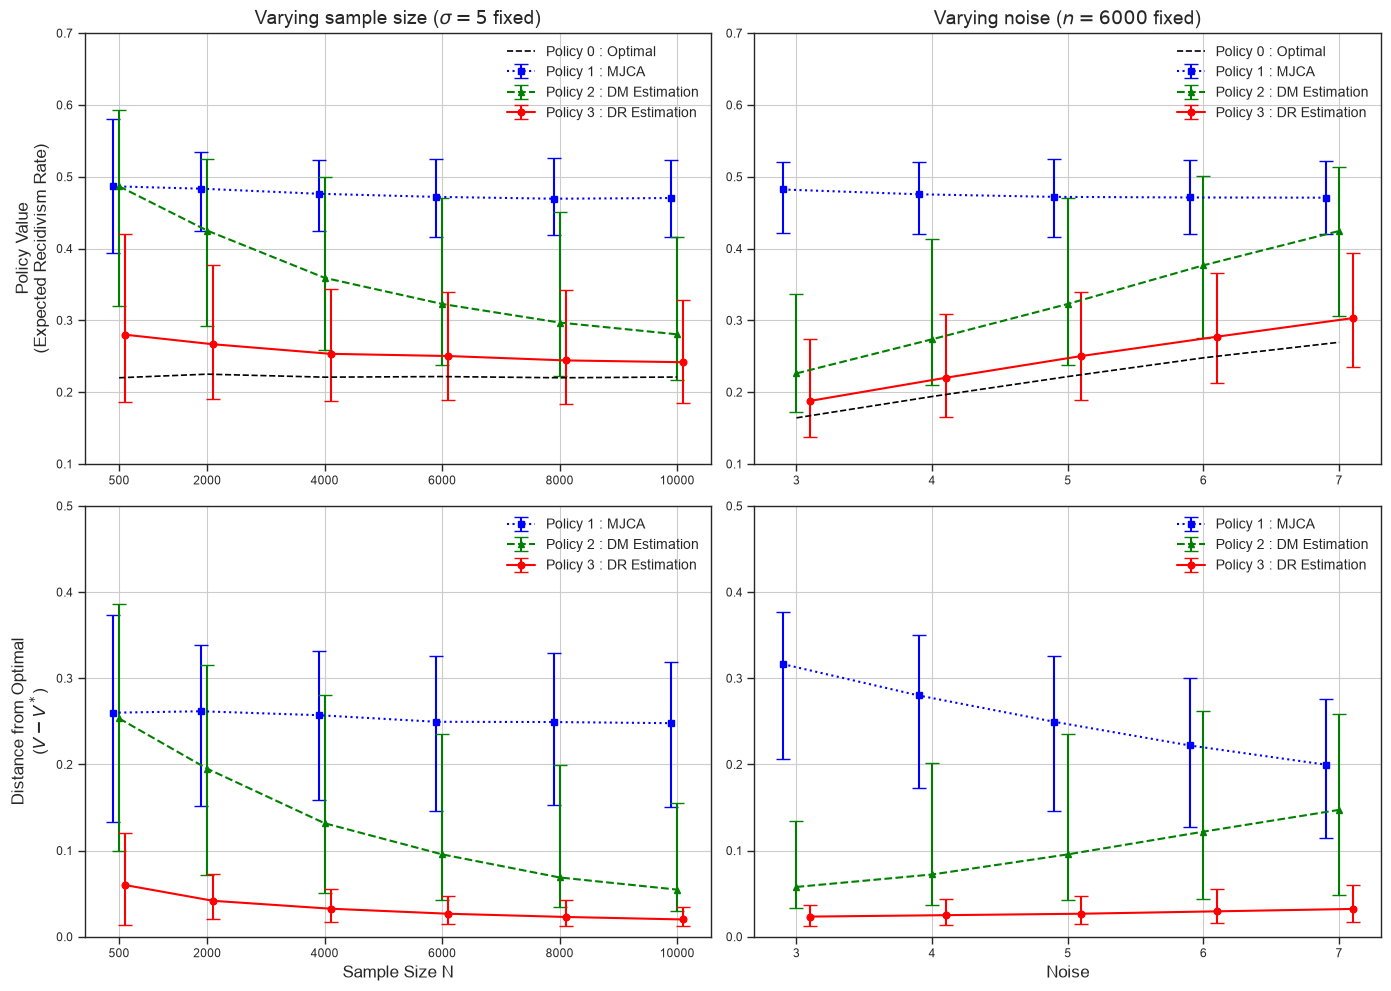

In [9]:
# @title 論文 Fig. 4 と同じ体裁の図（修正版）
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

def plot_data(results, param_levels, cases):
    median_results = {c: [] for c in cases}
    lower_bounds = {c: [] for c in cases}
    upper_bounds = {c: [] for c in cases}
    for _case in cases:
        for param in param_levels:
            data = np.array(results[param][_case])
            median_results[_case].append(np.median(data))
            lower_bounds[_case].append(np.percentile(data, 2.5))
            upper_bounds[_case].append(np.percentile(data, 97.5))
    return median_results, lower_bounds, upper_bounds


def diff_data(results, param_levels, cases):
    diff_median_results = {c: [] for c in cases}
    diff_lower_bounds = {c: [] for c in cases}
    diff_upper_bounds = {c: [] for c in cases}
    for _case in cases:
        for param in param_levels:
            d = np.array(results[param][_case]) - np.array(results[param]['Case0'])
            diff_median_results[_case].append(np.median(d))
            diff_lower_bounds[_case].append(np.percentile(d, 2.5))
            diff_upper_bounds[_case].append(np.percentile(d, 97.5))
    return diff_median_results, diff_lower_bounds, diff_upper_bounds


def paper_figure(case3_key, fname):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    cases = ['Case0', 'Case1', 'Case2', case3_key]
    labels = ['Policy 0 : Optimal', 'Policy 1 : MJCA', 'Policy 2 : DM Estimation', 'Policy 3 : DR Estimation']
    colors = ['black', 'blue', 'green', 'red']
    line_styles = ['-.', ':', '--', '-']
    markers = ['s', 's', '^', 'o']
    for col, (results, levels, offset, title) in enumerate([
            (sample_results, sample_sizes, 100, 'Varying sample size ($\\sigma = 5$ fixed)'),
            (noise_results, noise_levels, 0.1, 'Varying noise ($n = 6000$ fixed)')]):
        ax = axes[0, col]
        med, lo, hi = plot_data(results, levels, cases)
        case_offsets = [0, -offset, 0, offset]
        for i, (_case, _label, _color) in enumerate(zip(cases, labels, colors)):
            if _case == 'Case0':
                continue
            xs = [lv + case_offsets[i] for lv in levels]
            ax.errorbar(xs, med[_case], yerr=[np.array(med[_case]) - np.array(lo[_case]), np.array(hi[_case]) - np.array(med[_case])],
                        marker=markers[i], label=_label, color=_color, capsize=5, linestyle=line_styles[i], linewidth=1.5)
        ax.set_xticks(levels); ax.set_xticklabels(levels)
        ax.plot(levels, med['Case0'], 'k--', label=labels[0])
        if col == 0:
            ax.set_ylabel('Policy Value\n(Expected Recidivism Rate)', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.legend(fontsize=10, frameon=False)
        ax.set_ylim(0.1, 0.7)
        ax.grid(True)

        ax = axes[1, col]
        dcases = cases[1:]
        dmed, dlo, dhi = diff_data(results, levels, dcases)
        d_offsets = [-offset, 0, offset]
        for i, (_case, _label, _color) in enumerate(zip(dcases, labels[1:], colors[1:])):
            xs = [lv + d_offsets[i] for lv in levels]
            ax.errorbar(xs, dmed[_case], yerr=[np.array(dmed[_case]) - np.array(dlo[_case]), np.array(dhi[_case]) - np.array(dmed[_case])],
                        marker=markers[i + 1], label=_label, color=_color, linestyle=line_styles[i + 1], capsize=5, linewidth=1.5)
        ax.set_xticks(levels); ax.set_xticklabels(levels)
        ax.set_xlabel('Sample Size N' if col == 0 else 'Noise', fontsize=12)
        if col == 0:
            ax.set_ylabel('Distance from Optimal\n($V - V^*$)', fontsize=12)
        ax.legend(fontsize=10, frameon=False)
        ax.set_ylim(0.0, 0.5)
        ax.grid(True)
    plt.tight_layout()
    plt.savefig(OUT / fname, dpi=300, format='png', bbox_inches='tight')
    plt.show()

paper_figure('Case3', 'recidivism_errorbar_fixed.png')

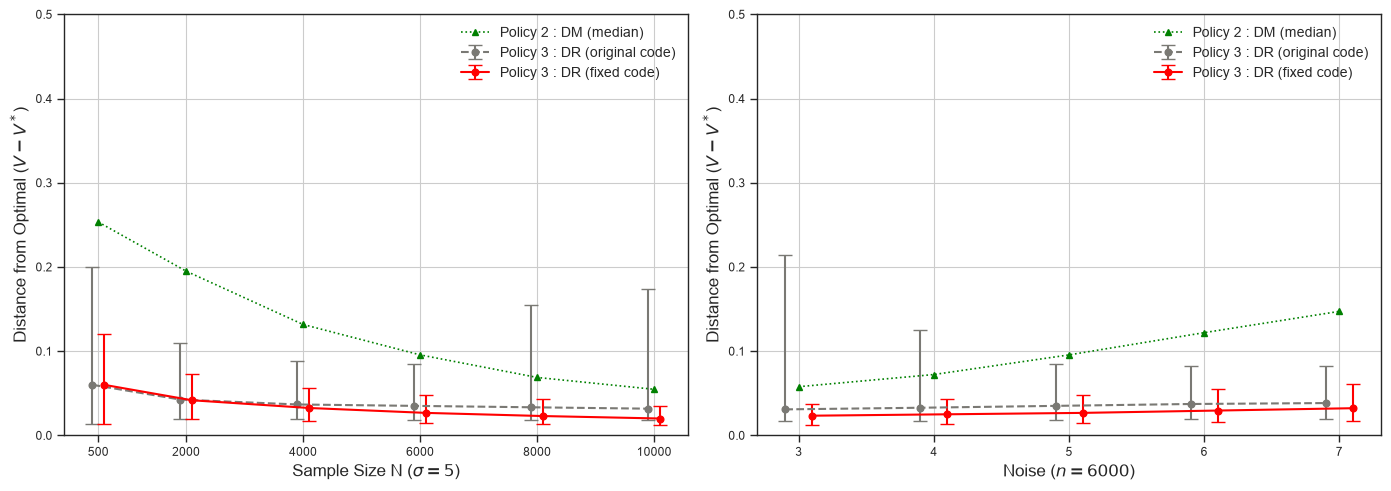

In [10]:
# @title 修正前後の Case 3 の比較
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (results, levels, offset, xlabel) in zip(axes, [
        (sample_results, sample_sizes, 100, 'Sample Size N ($\\sigma = 5$)'),
        (noise_results, noise_levels, 0.1, 'Noise ($n = 6000$)')]):
    for c, lab, color, ls, dx in [('Case3_orig', 'Policy 3 : DR (original code)', '#7a7974', '--', -offset),
                                  ('Case3', 'Policy 3 : DR (fixed code)', 'red', '-', offset)]:
        d = [np.array(results[lv][c]) - np.array(results[lv]['Case0']) for lv in levels]
        med = np.array([np.median(x) for x in d])
        lo = np.array([np.percentile(x, 2.5) for x in d]); hi = np.array([np.percentile(x, 97.5) for x in d])
        ax.errorbar([lv + dx for lv in levels], med, yerr=[med - lo, hi - med], marker='o', color=color, ls=ls,
                    capsize=5, lw=1.5, label=lab)
    d2 = [np.array(results[lv]['Case2']) - np.array(results[lv]['Case0']) for lv in levels]
    ax.plot(levels, [np.median(x) for x in d2], color='green', ls=':', marker='^', label='Policy 2 : DM (median)')
    ax.set_xticks(levels); ax.set_xticklabels(levels)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Distance from Optimal ($V - V^*$)', fontsize=12)
    ax.set_ylim(0.0, 0.5); ax.grid(True); ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig(OUT / 'case3_fixed_vs_orig.png', dpi=300, bbox_inches='tight')
plt.show()